### 0. Import Libraries

In [52]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

%matplotlib inline

# 1. Load Data

In [25]:
cars_df = sns.load_dataset("mpg").dropna()
cars_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# 2. Stateless Feature Engineeing

## 2.1 Power-to-weight ratio

In [27]:
cars_df[["horsepower","weight"]].corr()

,horsepower,weight
horsepower,1.000000,0.864538
weight,0.864538,1.000000


In [28]:
cars_df["power_to_weight"] = cars_df["horsepower"] / cars_df["weight"]

<AxesSubplot:ylabel='Frequency'>

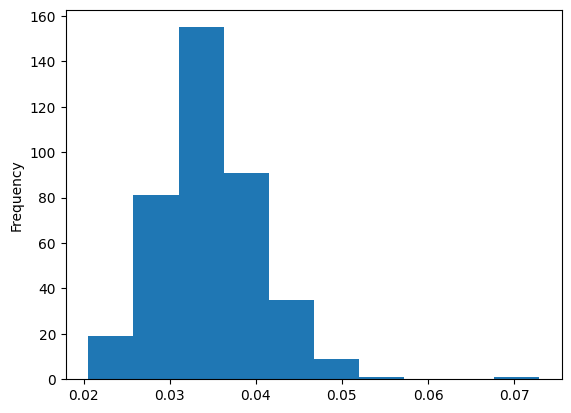

In [29]:
cars_df["power_to_weight"].plot(kind="hist")

## 2.2 Car Manunfacturer

In [31]:
cars_df["brand"] = cars_df["name"].str.split().str[0]

In [32]:
cars_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,power_to_weight,brand
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,0.037100,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,0.044679,buick
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,0.043655,plymouth
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,0.043694,amc
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,0.040591,ford


In [33]:
cars_df["brand"].value_counts(normalize=True)*100

ford             12.244898
chevrolet        10.969388
plymouth          7.908163
dodge             7.142857
amc               6.887755
toyota            6.377551
datsun            5.867347
buick             4.336735
pontiac           4.081633
volkswagen        3.826531
honda             3.316327
mercury           2.806122
mazda             2.551020
oldsmobile        2.551020
fiat              2.040816
peugeot           2.040816
audi              1.785714
vw                1.530612
chrysler          1.530612
volvo             1.530612
opel              1.020408
saab              1.020408
subaru            1.020408
chevy             0.765306
renault           0.765306
maxda             0.510204
cadillac          0.510204
bmw               0.510204
mercedes-benz     0.510204
triumph           0.255102
vokswagen         0.255102
mercedes          0.255102
hi                0.255102
capri             0.255102
chevroelt         0.255102
toyouta           0.255102
nissan            0.255102
N

# 3. Choose `X` & `y` 

In [34]:
cars_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name', 'power_to_weight',
       'brand'],
      dtype='object')

In [35]:
X = cars_df.drop(columns=["mpg", "name", "horsepower", "weight"])

y= cars_df["mpg"]

# 4. Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=100)

# 5. Train and Test Transformation Pipelines

In [39]:
# 1. Selecting columns to transform
num_clns = X_train.select_dtypes(include="number").columns
cat_clns = X_train.select_dtypes(include="object").columns

Index(['origin', 'brand'], dtype='object')

In [44]:
# 2. Transform num features
scaler = StandardScaler().set_output(transform="pandas")
X_train_num_prep = scaler.fit_transform(  X_train[num_clns]   )
X_test_num_prep = scaler.transform(  X_test[num_clns] )


In [47]:
# 3. Transform cat features
enc = OneHotEncoder(
                drop="first",
                sparse_output=False,
                handle_unknown="ignore"
).set_output(transform="pandas")

X_train_cat_prep = enc.fit_transform( X_train[ cat_clns ] )
X_test_cat_prep = enc.transform(X_test[ cat_clns ])

/Users/moe/.pyenv/versions/3.10.6/envs/DS/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [50]:
# 4. Concat
X_train_prep = pd.concat([X_train_num_prep, X_train_cat_prep], axis=1)
X_test_prep = pd.concat( [X_test_num_prep, X_test_cat_prep], axis=1)

X_train_prep.head()

,cylinders,displacement,acceleration,model_year,power_to_weight,origin_japan,origin_usa,brand_audi,brand_bmw,brand_buick,...,brand_pontiac,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_toyouta,brand_vokswagen,brand_volkswagen,brand_volvo,brand_vw
171,-0.842865,-0.567702,-0.730328,-0.292366,0.093666,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
267,-0.842865,-0.567702,-0.479922,0.525066,0.363868,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
392,-0.842865,-0.407965,0.629017,1.614975,-0.764881,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
243,-1.417356,-1.075099,-0.730328,0.252588,0.933604,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
251,1.455096,1.010869,-0.980734,0.525066,0.676147,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 5. Fit Model

In [51]:
ln_model = LinearRegression()

ln_model.fit(X_train_prep, y_train)

LinearRegression()

# 6. Evaluate Model

In [55]:
y_prep = ln_model.predict(X_test_prep)

RMSE_score = root_mean_squared_error(y_test, y_prep)

RMSE_score

3.9803121838935978